In [16]:
import os
import pandas as pd
from sqlalchemy import create_engine
from pathlib import Path
from dotenv import load_dotenv

env_path = Path("..") / ".env"  
load_dotenv(env_path)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_SCHEMA = os.getenv("DB_SCHEMA", "public")
DB_TABLE = os.getenv("DB_TABLE")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df = pd.read_sql(f'SELECT * FROM {DB_SCHEMA}."{DB_TABLE}";', engine)
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerid        7043 non-null   str  
 1   gender            7043 non-null   str  
 2   seniorcitizen     7043 non-null   str  
 3   partner           7043 non-null   str  
 4   dependents        7043 non-null   str  
 5   tenure            7043 non-null   str  
 6   phoneservice      7043 non-null   str  
 7   multiplelines     7043 non-null   str  
 8   internetservice   7043 non-null   str  
 9   onlinesecurity    7043 non-null   str  
 10  onlinebackup      7043 non-null   str  
 11  deviceprotection  7043 non-null   str  
 12  techsupport       7043 non-null   str  
 13  streamingtv       7043 non-null   str  
 14  streamingmovies   7043 non-null   str  
 15  contract          7043 non-null   str  
 16  paperlessbilling  7043 non-null   str  
 17  paymentmethod     7043 non-null   str  
 18 

In [18]:
df["seniorcitizen"] = pd.to_numeric(df["seniorcitizen"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["monthlycharges"] = pd.to_numeric(df["monthlycharges"], errors="coerce")
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")

In [19]:
df.shape

(7043, 21)

In [20]:
df.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [21]:
df = df.dropna()

In [22]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df["churn"].value_counts()

churn
No     5163
Yes    1869
Name: count, dtype: int64

In [25]:
df["churn"].value_counts(normalize=True) * 100

churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [26]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


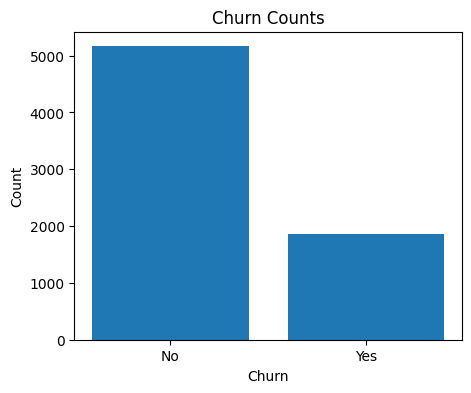

In [28]:
import matplotlib.pyplot as plt

counts = df["churn"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(counts.index, counts.values)
plt.title("Churn Counts")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

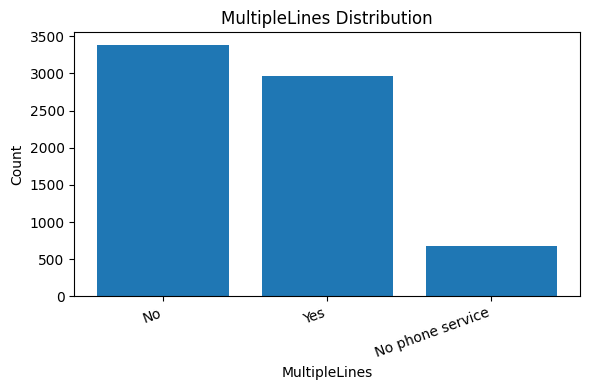

In [29]:
import matplotlib.pyplot as plt

counts = df["multiplelines"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("MultipleLines Distribution")
plt.xlabel("MultipleLines")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

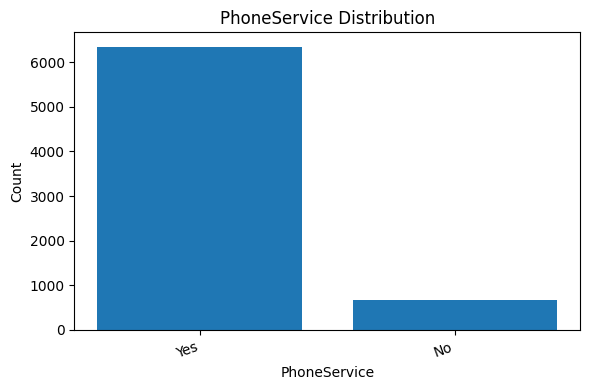

In [30]:
counts = df["phoneservice"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("PhoneService Distribution")
plt.xlabel("PhoneService")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

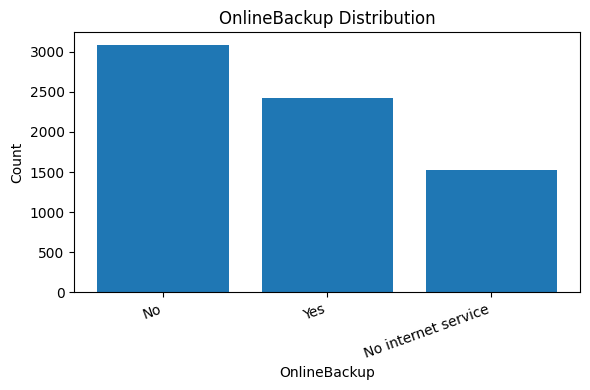

In [31]:
counts = df["onlinebackup"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("OnlineBackup Distribution")
plt.xlabel("OnlineBackup")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

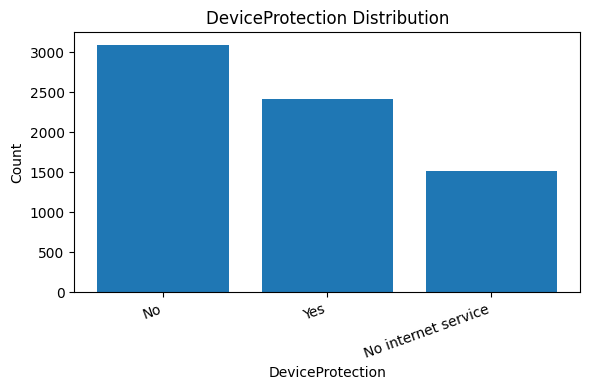

In [32]:
counts = df["deviceprotection"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("DeviceProtection Distribution")
plt.xlabel("DeviceProtection")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

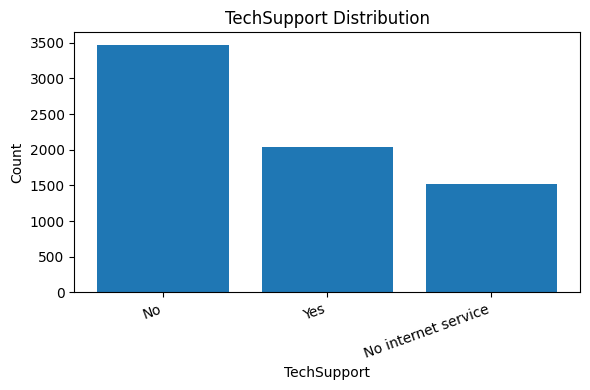

In [33]:
counts = df["techsupport"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("TechSupport Distribution")
plt.xlabel("TechSupport")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

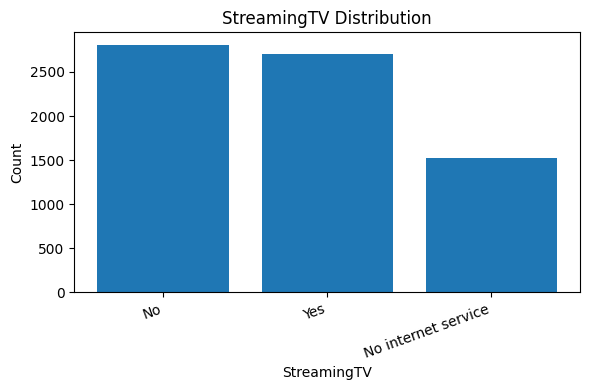

In [34]:
counts = df["streamingtv"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("StreamingTV Distribution")
plt.xlabel("StreamingTV")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


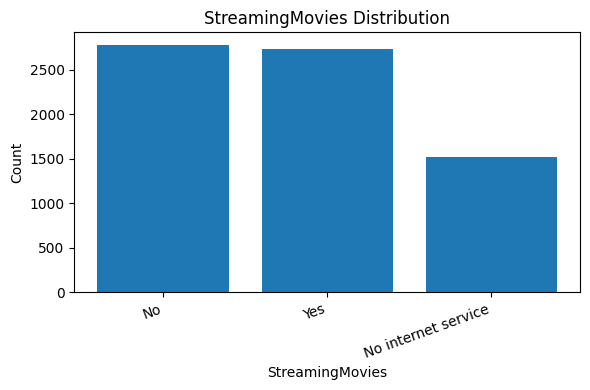

In [35]:
counts = df["streamingmovies"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("StreamingMovies Distribution")
plt.xlabel("StreamingMovies")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


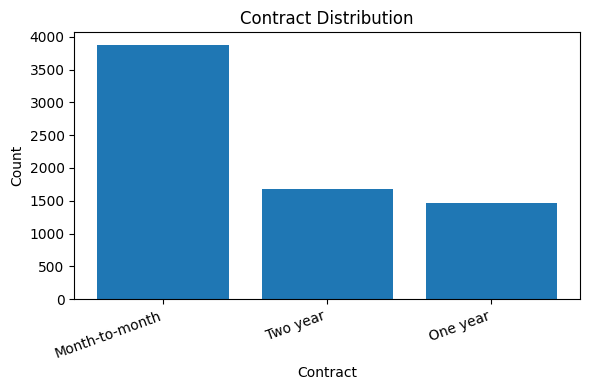

In [36]:
counts = df["contract"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Contract Distribution")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


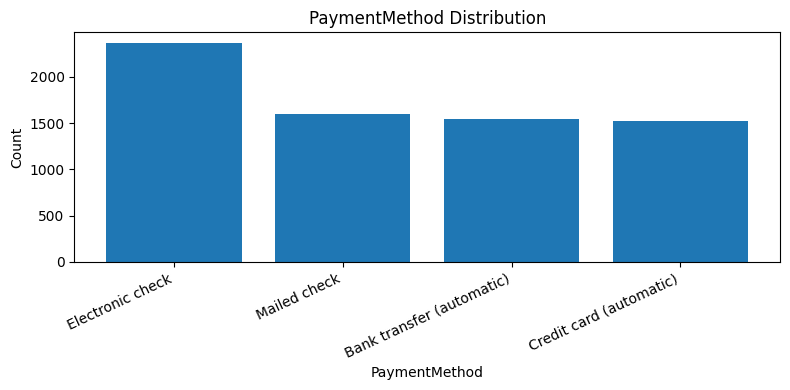

In [37]:
counts = df["paymentmethod"].value_counts()

plt.figure(figsize=(8,4))
plt.bar(counts.index, counts.values)
plt.title("PaymentMethod Distribution")
plt.xlabel("PaymentMethod")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

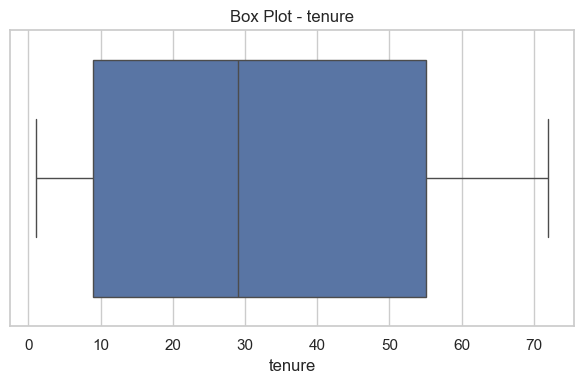

In [43]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,4))
sns.boxplot(x=df["tenure"])
plt.title("Box Plot - tenure")
plt.xlabel("tenure")
plt.tight_layout()
plt.show()


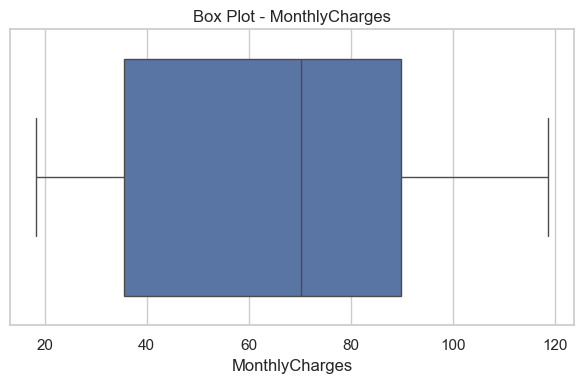

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["monthlycharges"])
plt.title("Box Plot - MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.tight_layout()
plt.show()

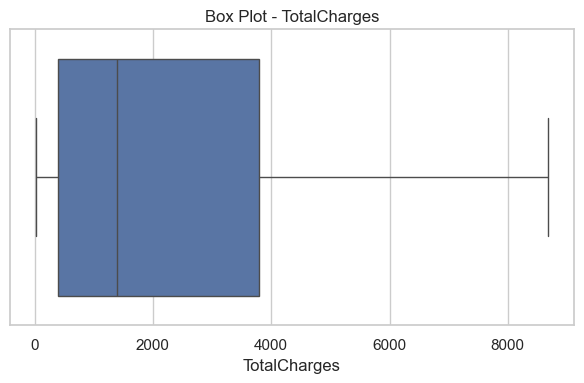

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["totalcharges"])
plt.title("Box Plot - TotalCharges")
plt.xlabel("TotalCharges")
plt.tight_layout()
plt.show()

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Target: Yes/No -> 1/0
y = (df["churn"] == "Yes").astype(int)

# Features: drop ID and target
X = df.drop(columns=["customerid", "churn"])

# Column types
num_cols = ["seniorcitizen", "tenure", "monthlycharges", "totalcharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

# One-hot encode categorical, keep numeric as-is
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

lr_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("lr", LogisticRegression(max_iter=3000, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("LOGISTIC REGRESSION (Base)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

LOGISTIC REGRESSION (Base)
Accuracy: 0.8088130774697939
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1033
           1       0.67      0.55      0.60       374

    accuracy                           0.81      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

lr_param_grid = [
    {
        "lr__solver": ["liblinear"],
        "lr__penalty": ["l1", "l2"],
        "lr__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "lr__solver": ["lbfgs"],
        "lr__penalty": ["l2"],
        "lr__C": [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

lr_grid = GridSearchCV(
    lr_model,
    param_grid=lr_param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("\nLOGISTIC REGRESSION (Tuned)")
print("Best Params:", lr_grid.best_params_)
print("Best CV Accuracy:", lr_grid.best_score_)

lr_best = lr_grid.best_estimator_
lr_best_pred = lr_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, lr_best_pred))
print(classification_report(y_test, lr_best_pred))

Fitting 5 folds for each of 18 candidates, totalling 90 fits

LOGISTIC REGRESSION (Tuned)
Best Params: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Best CV Accuracy: 0.8023111111111112
Test Accuracy: 0.8095238095238095
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1033
           1       0.67      0.55      0.61       374

    accuracy                           0.81      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



d:\Intern\Customer-churn\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
